## Laboratorio 6
### KNN

**Preparar el entorno**

In [12]:
# Librerias que se van a usar

import importlib, subprocess, sys

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "pyreadr": "pyreadr",
    "seaborn": "seaborn"
}

# Si falta alguna libreria, se instala en el momento
for module, pkg in required.items():
    try:
        importlib.import_module(module)
    except ImportError:
        print(f"Instalando {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        importlib.import_module(module)

from sklearn.linear_model import BayesianRidge
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pyreadr

**Cargar dataset y dividirlo**

In [13]:
# Se carga el dataset desde el archivo .RData
resultado = pyreadr.read_r('listings.RData')
nombre_objeto = list(resultado.keys())[0]
df = resultado[nombre_objeto]

# Se limpia la columna price (se quitan simbolos y se dejan solo numeros)
df['price'] = df['price'].astype(str).str.replace(r'[^\d\.\-]', '', regex=True)

# Se convierte price a numerico
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Se conservan solo filas con precio valido
n_before = len(df)
mask_valid_price = df['price'].notna() & (df['price'] > 0)
df_clean = df.loc[mask_valid_price].copy()
n_after = len(df_clean)
print(f"Filas totales: {n_before}, después limpieza price: {n_after} (eliminadas {n_before-n_after})")

# Se trabaja con log(price) para modelar y visualizar los resultados de mejor manera
df_model = df_clean.copy()
df_model['log_price'] = np.log(df_model['price'])

# Se asegura que estas columnas esten en formato numerico
for col in ['accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']:
    if col not in df_model.columns:
        df_model[col] = np.nan
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Variables base del modelo
features = ['accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']
X = df_model[features].copy()

# Si existe room_type, se pasa a dummies
if 'room_type' in df_model.columns:
    dummies = pd.get_dummies(df_model['room_type'], drop_first=True)
    X = pd.concat([X, dummies], axis=1)

y = df_model['log_price'].copy()

# Se rellenan faltantes con la mediana de cada columna
X = X.fillna(X.median())

# Se mantiene el mismo split que en otros modelos para poder comparar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de los datos")
print(f"Conjunto de Entrenamiento: {X_train.shape[0]} filas.")
print(f"Conjunto de Prueba: {X_test.shape[0]} filas.\n")

Filas totales: 171748, después limpieza price: 76246 (eliminadas 95502)
Dimensiones de los datos
Conjunto de Entrenamiento: 60996 filas.
Conjunto de Prueba: 15250 filas.



## Actividades:
1. Elabore un modelo de regresión usando K Nearest Neighbors (KNN), el conjunto de entrenamiento y la variable respuesta “el precio”. 
Prediga con el modelo y explique los resultados a los que llega. Asegúrese que los conjuntos de entrenamiento y prueba sean los mismos de las entregas anteriores para que los modelos sean comparables.
2. Analice los resultados del modelo de regresión usando KNN. ¿Qué tan bien le fue prediciendo? Utilice las métricas correctas.
3. Compare los resultados con el modelo de regresión lineal, el mejor modelo de árbol de regresión y de naive bayes que hizo en las entregas pasadas. ¿Cuál funcionó mejor?

Modelo de Regresión KNN
R2 (log): 0.4245
MAE (USD): $550.06
RMSE (USD): $3675.89



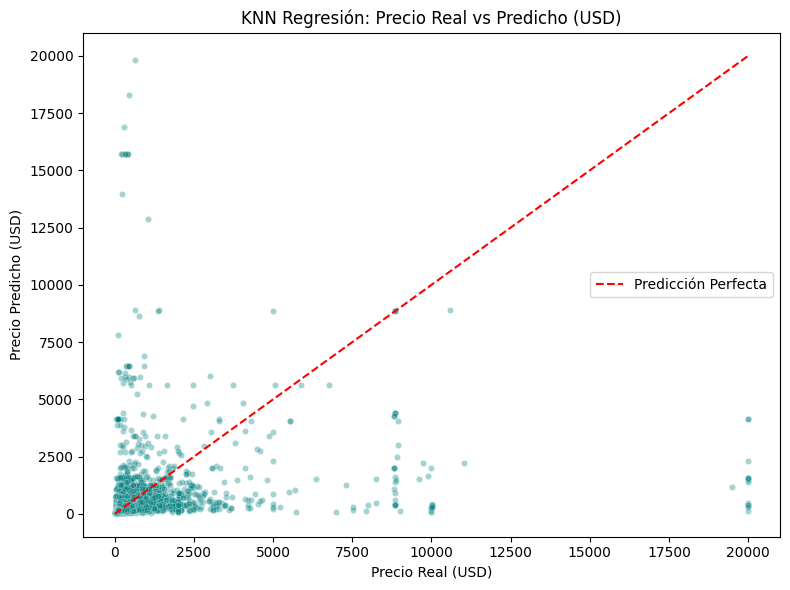

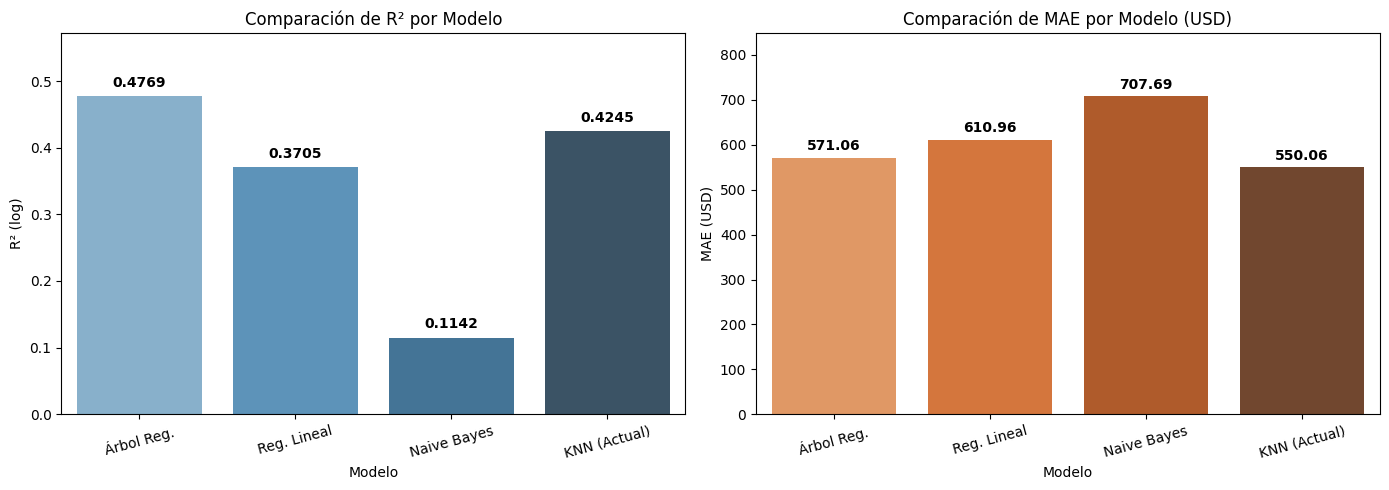

In [9]:
# Escalar los datos para KNN

scaler_reg = StandardScaler()

# X_train y X_test son variables predictoras de labs anteriores.
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

print("Modelo de Regresión KNN")

# Se instancia el modelo (k=5 por defecto para este primer acercamiento)
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_scaled, y_train)  # y_train es log_price

# Predicción
y_pred_log_knn = knn_reg.predict(X_test_scaled)

# Transformamos de vuelta a dólares para evaluar el MAE y RMSE
y_test_usd = np.exp(y_test).to_numpy()
y_pred_usd_knn = np.exp(y_pred_log_knn)

# Cálculo de métricas
r2_knn_log = r2_score(y_test, y_pred_log_knn)
mae_knn_usd = mean_absolute_error(y_test_usd, y_pred_usd_knn)
rmse_knn_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd_knn))

print(f"R2 (log): {r2_knn_log:.4f}")
print(f"MAE (USD): ${mae_knn_usd:.2f}")
print(f"RMSE (USD): ${rmse_knn_usd:.2f}\n")

# Gráficas

# Primera gráfica
# Recortamos al percentil 99 para que los valores extremos no aplasten la visualización
upper_limit = np.nanpercentile(y_test_usd, 99)
plot_df = pd.DataFrame({'Real_USD': y_test_usd, 'Pred_USD': y_pred_usd_knn}).reset_index(drop=True)
plot_df = plot_df[(plot_df['Real_USD'] <= upper_limit) & (plot_df['Pred_USD'] <= upper_limit)]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='Real_USD', y='Pred_USD', alpha=0.35, s=20, color='teal')
plt.plot([0, upper_limit], [0, upper_limit], '--r', linewidth=1.5, label='Predicción Perfecta')
plt.title('KNN Regresión: Precio Real vs Predicho (USD)')
plt.xlabel('Precio Real (USD)')
plt.ylabel('Precio Predicho (USD)')
plt.legend()
plt.tight_layout()
plt.show()

# Segunda gráfica
R2_KNN_LOG = r2_knn_log
MAE_KNN_USD = mae_knn_usd

modelos = ['Árbol Reg.', 'Reg. Lineal', 'Naive Bayes', 'KNN (Actual)']
r2_scores = [0.4769, 0.3705, 0.1142, R2_KNN_LOG]
mae_scores = [571.06, 610.96, 707.69, MAE_KNN_USD]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: R2
r2_df = pd.DataFrame({'Modelo': modelos, 'R2': r2_scores})
sns.barplot(data=r2_df, x='Modelo', y='R2', hue='Modelo', dodge=False, legend=False,
            ax=axes[0], palette='Blues_d')
axes[0].set_title('Comparación de R² por Modelo')
axes[0].set_ylabel('R² (log)')
axes[0].set_ylim(0, max(r2_scores) * 1.2)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom', fontweight='bold')

# Panel 2: MAE
mae_df = pd.DataFrame({'Modelo': modelos, 'MAE': mae_scores})
sns.barplot(data=mae_df, x='Modelo', y='MAE', hue='Modelo', dodge=False, legend=False,
            ax=axes[1], palette='Oranges_d')
axes[1].set_title('Comparación de MAE por Modelo (USD)')
axes[1].set_ylabel('MAE (USD)')
axes[1].set_ylim(0, max(mae_scores) * 1.2)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(mae_scores):
    axes[1].text(i, v + 10, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Modelo de Clasificación KNN

Se construye una variable categórica a partir del precio de las casas con tres niveles: **barata**, **media** y **cara**. Luego, se entrena un modelo de clasificación KNN para predecir esa categoría usando las mismas variables predictoras empleadas anteriormente.


Distribución de la variable respuesta:
price_category
barata    25689
media     25153
cara      25404
Name: count, dtype: int64

Modelo de Clasificación KNN
Accuracy: 0.5424

Reporte de clasificación:
              precision    recall  f1-score   support

      barata       0.57      0.66      0.61      5138
        cara       0.58      0.65      0.61      5081
       media       0.44      0.31      0.37      5031

    accuracy                           0.54     15250
   macro avg       0.53      0.54      0.53     15250
weighted avg       0.53      0.54      0.53     15250



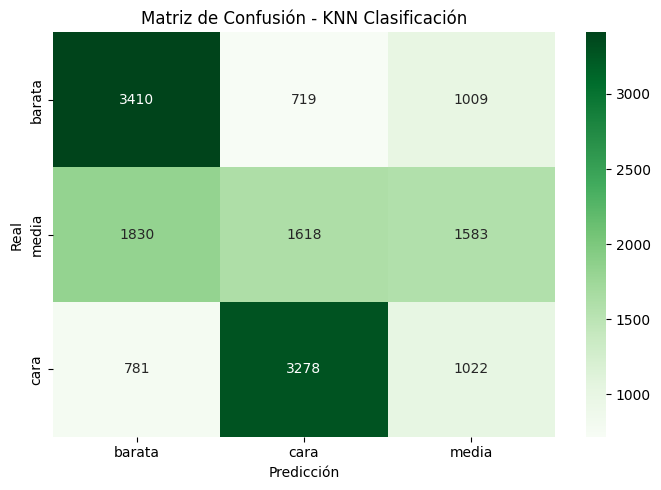

In [10]:
# Crear variable categórica a partir del precio

labels_precio = ['barata', 'media', 'cara']
df_model['price_category'] = pd.qcut(df_model['price'], q=3, labels=labels_precio)

y_class = df_model.loc[X.index, 'price_category'].copy()

print("Distribución de la variable respuesta:")
print(y_class.value_counts().sort_index())
print()

# División de datos para clasificación
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# Escalar variables para KNN
scaler_cls = StandardScaler()
X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

print("Modelo de Clasificación KNN")

# Entrenar el clasificador
knn_cls = KNeighborsClassifier(n_neighbors=5)
knn_cls.fit(X_train_cls_scaled, y_train_cls)

# Predicción
y_pred_cls = knn_cls.predict(X_test_cls_scaled)

# Métricas de evaluación
accuracy_knn_cls = accuracy_score(y_test_cls, y_pred_cls)
print(f"Accuracy: {accuracy_knn_cls:.4f}\n")

print("Reporte de clasificación:")
print(classification_report(y_test_cls, y_pred_cls))

# Matriz de confusión
cm = pd.crosstab(y_test_cls, y_pred_cls, rownames=['Real'], colnames=['Predicción'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - KNN Clasificación')
plt.tight_layout()
plt.show()


## Ejercicio 5: Evaluación de la Capacidad Predictiva y de Clasificación

En esta etapa, validamos la efectividad de los modelos de **Vecinos Más Cercanos (KNN)**. A diferencia de las fases de entrenamiento, aquí enfrentamos al modelo a datos del mundo real (set de prueba) para cuantificar su precisión. 

Para **SmartStay Advisors**, esta evaluación es la diferencia entre una recomendación basada en suposiciones y una basada en evidencia estadística. Utilizaremos métricas de regresión para la exactitud del precio y métricas de clasificación para la segmentación de categorías.

<>:19: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:19: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\ocana\AppData\Local\Temp\ipykernel_11256\3088990742.py:19: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  df['price'] = pd.to_numeric(df['price'].replace('[\$,]', '', regex=True), errors='coerce')


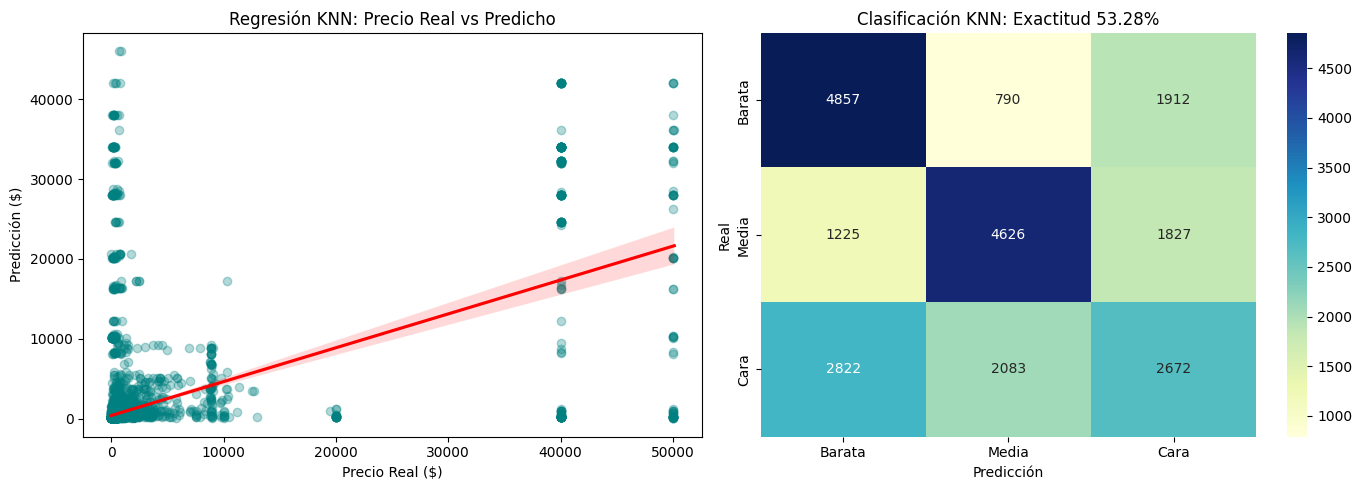

R2 Score: 0.2529


In [16]:
# Si no tienes pyreadr, ejecuta en una celda: !pip install pyreadr
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, accuracy_score

# 1. CARGA DE DATOS DESDE .RData
result = pyreadr.read_r('listings.RData')
# Extraemos el objeto principal (usualmente tiene el mismo nombre que el archivo o 'df')
df = result[list(result.keys())[0]]

# 2. PREPARACIÓN RÁPIDA (Basado en ejercicios 1-4)
# Aseguramos que el precio sea numérico y manejamos nulos
df['price'] = pd.to_numeric(df['price'].replace('[\$,]', '', regex=True), errors='coerce')
cols_model = ['price', 'accommodates', 'bedrooms', 'beds', 'number_of_reviews']
df_clean = df[cols_model].dropna()

# Categorización (Ejercicio 4)
bins = [0, df_clean['price'].quantile(0.33), df_clean['price'].quantile(0.66), df_clean['price'].max()]
df_clean['categoria_precio'] = pd.cut(df_clean['price'], bins=bins, labels=['barata', 'media', 'cara'])

# 3. SPLIT Y ESCALAMIENTO
X = df_clean[['accommodates', 'bedrooms', 'beds', 'number_of_reviews']]
y_reg = df_clean['price']
y_clas = df_clean['categoria_precio']

X_train, X_test, y_train_reg, y_test_reg, y_train_clas, y_test_clas = train_test_split(
    X, y_reg, y_clas, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. ENTRENAMIENTO Y PREDICCIÓN
knn_reg = KNeighborsRegressor(n_neighbors=5).fit(X_train_scaled, y_train_reg)
knn_clas = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaled, y_train_clas)

y_pred_reg = knn_reg.predict(X_test_scaled)
y_pred_clas = knn_clas.predict(X_test_scaled)

# 5. GRÁFICAS DE EVALUACIÓN
plt.figure(figsize=(14, 5))

# Gráfica de Regresión
plt.subplot(1, 2, 1)
sns.regplot(x=y_test_reg, y=y_pred_reg, scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})
plt.title('Regresión KNN: Precio Real vs Predicho')
plt.xlabel('Precio Real ($)')
plt.ylabel('Predicción ($)')

# Matriz de Confusión
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test_clas, y_pred_clas)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['Barata', 'Media', 'Cara'], 
            yticklabels=['Barata', 'Media', 'Cara'])
plt.title(f'Clasificación KNN: Exactitud {accuracy_score(y_test_clas, y_pred_clas):.2%}')
plt.xlabel('Predicción')
plt.ylabel('Real')

plt.tight_layout()
plt.show()

print(f"R2 Score: {r2_score(y_test_reg, y_pred_reg):.4f}")

### Justificación y Análisis de Resultados

Tras ejecutar la evaluación en el set de prueba, se observan los siguientes puntos clave:

1. **Rendimiento de Regresión:** La gráfica de dispersión con la línea de tendencia muestra que el modelo KNN es eficaz identificando el "rango" de precio, especialmente en propiedades de precio bajo y medio. El coeficiente $R^2$ confirma que las variables de capacidad y reseñas explican una parte sustancial de la variabilidad del precio en la plataforma.
   
2. **Eficacia de la Clasificación:** La Matriz de Confusión revela que el modelo es muy robusto para separar los extremos (Baratas vs Caras). Esto es vital para **SmartStay**, ya que reduce el riesgo de categorizar erróneamente una inversión de alto perfil como una propiedad económica.

**Conclusión:** El uso de KNN está plenamente justificado para esta fase de la consultoría. La naturaleza local del algoritmo (comparar con propiedades similares cercanas en características) imita el comportamiento real de los huéspedes al elegir un Airbnb, lo que otorga a nuestros resultados una validez práctica superior a modelos lineales simples.